# Attention and Transformers with PyTorch

Modelo montado a partir do notebook transformer_attention_bert_inc.ipynb visto na aula 5.




## 0. Imports

In [ ]:
import math
import re
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## 1. Part 1 — Dataset, tokenization, vocabulary, encoding

O Dataset para treinamento possui 171 mil eventos coletados.

Para poder usar no colab mais rapidamente, é melhor subir o zip e executar a linha de unzip a seguir.

In [59]:
!unzip custom_dataset_v2_mini.zip

Archive:  custom_dataset_v2_mini.zip
  inflating: custom_dataset_v2_mini.csv  


Vamos montar 3 dataframes iniciais:


* df = dataset que será usado para se fazer amostragem balanceada e depois a divisão entre treino (80%) e validação (20%)
* dg = dataset com os 225 exemplos classificados do Dataset do professor (125 de dataset-exemplos.csv + 100 de subm1_labels_revealed.csv)
* dh = dataset não etiquetado que será classificado para submissão



In [61]:
import pandas as pd

df = pd.read_csv("./custom_dataset_v2_mini.csv", sep=";")
dg1 = pd.read_csv("./dataset-exemplos.csv", sep=";")
dg2 = pd.read_csv("./subm1_labels_revealed.csv", sep=";")
dg = pd.concat([dg1, dg2], ignore_index=True)
dh = pd.read_csv("./subm2.csv", sep=";")

df['Label'].value_counts()

,count
Label,
Human,70610
Google,30000
Meta,30000
OpenAI,30000
Anthropic,10305


Para se assemelhar ao dataset do professor, será montado a lista com a maior quantidade possível de eventos distintos para treino e validação na seguinte proporção:

Human, Google, Meta, OpenAI, Anthropic = 3,1,1,1,1

Os eventos selecionados para cada classe serão os que tiverem maior contagem de palavras únicas em comum com os eventos etiquetados pelo professor, para aumentar a semelhança entre os dados de treino utilizado no nosso modelo com o dataset utilizado para teste montado pelo professor.

O tamanho de cada sentença será limitado a 120 tokens.

O tamanho do vocabulário será de 50 mil tokens (montado a partir dos eventos completos, não limitados a 120).





In [115]:
import re
max_len = 120

contagens = df['Label'].value_counts()
# Número final de amostras por classe
amostras_por_classe = min(contagens)

label_map = {
    "Human": 0,
    "Anthropic": 1,
    "Google": 2,
    "OpenAI": 3,
    "Meta": 4
}

# Keep the existing `ds` creation logic unchanged, which creates `ds` from `dg`
ds = [
    {'text': row.Text, 'label': label_map[row.Label]}
    for row in dg.itertuples(index=False)
]

def temp_tokenize(text):
    """Temporary tokenization function for correlation score calculation."""
    text = text.lower()
    text = re.sub(r"<.*?>", "", text) # Remove HTML tags
    text = re.sub(r"[^a-zA-Z]", " ", text) # Replace non-alphabetic characters with spaces
    return text.split()[:max_len]

# 2. Extract unique words from `dg` (test dataset texts)
ds_unique_words = set()
for text in dg['Text']:
    ds_unique_words.update(temp_tokenize(text))

for text in dh['Text']:
    ds_unique_words.update(temp_tokenize(text))

# 3. Calculate a 'correlation score' for each text in the original `df` DataFrame
scored_dt_candidates = []
for index, row in df.iterrows(): # Iterate through the *original* df
    text_tokens = set(temp_tokenize(row.Text))
    correlation_score = len(text_tokens.intersection(ds_unique_words))
    scored_dt_candidates.append({
        'text': row.Text,
        'label': label_map[row.Label],
        'correlation_score': correlation_score
    })

# Convert to DataFrame for easier grouping and sorting
scored_dt_df = pd.DataFrame(scored_dt_candidates)

# 4. Filter the texts to create the final `dt` list
dt = []
# `amostras_por_classe` is defined in cell 8153be54 and should be accessible
for label_name, label_id in label_map.items():
    class_data = scored_dt_df[scored_dt_df['label'] == label_id]
    # Sort by correlation_score in descending order and select top N
    sorted_class_data = class_data.sort_values(by='correlation_score', ascending=False)
    selected_samples = sorted_class_data.head(amostras_por_classe if label_id > 0 else 3*amostras_por_classe)
    for _, row in selected_samples.iterrows():
        dt.append({'text': row.text, 'label': row.label})

pd.DataFrame(dt)['label'].value_counts()

,count
label,
0,30915
1,10305
2,10305
3,10305
4,10305


In [80]:
# Reduce dataset size for faster training during class
train_data = dt
test_data = ds

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 72135
Test size: 225


In [82]:
from sklearn.model_selection import StratifiedShuffleSplit

max_words = 50000

def tokenize(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text.split()

def clean_text(text): ## standardization
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

def build_vocab(texts, max_words = 10000): ## building the vocabulary
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    most_common = counter.most_common(max_words-2)
    vocab = {"<pad>": 0, "<unk>": 1}
    for i, (word, _) in enumerate(most_common, start=2):
        vocab[word] = i
    return vocab

word_index = build_vocab([text["text"] for text in train_data], max_words)

def encode(text, word_index, max_len=120): ## integer encoding
    tokens = tokenize(text)

    sequence = [word_index.get(word, 1) for word in tokens]
    # Truncate
    sequence = sequence[:max_len]
    # Pad
    if len(sequence) < max_len:
        sequence += [0] * (max_len - len(sequence))

    return torch.tensor(sequence, dtype=torch.long)

def collate(batch):
    X, y = [], []

    for item in batch:
        X.append(encode(item["text"], word_index))
        y.append(item["label"])

    return torch.stack(X), torch.tensor(y)

# Extract labels for stratification
labels = [item['label'] for item in train_data]

# Use StratifiedShuffleSplit for balanced train-validation split
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get indices for train and validation sets
for train_idx, val_idx in splitter.split(train_data, labels):
    train_subset = [train_data[i] for i in train_idx]
    val_subset = [train_data[i] for i in val_idx]

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=collate)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collate)

print(f"Original train_data size: {len(train_data)}")
print(f"Train subset size: {len(train_subset)}")
print(f"Validation subset size: {len(val_subset)}")

Original train_data size: 72135
Train subset size: 57708
Validation subset size: 14427


## 2. Transformer Encoder Classifier

In [83]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_classes, max_len, dropout_rate=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)
        self.dropout = nn.Dropout(dropout_rate)

        # complete#
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.dropout_attn = nn.Dropout(dropout_rate)

        self.norm1 = nn.LayerNorm(embed_dim)

        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.dropout_ff = nn.Dropout(dropout_rate)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)

        x = self.embedding(x) + self.pos_embedding(positions)
        x = self.dropout(x)

        # complete#
        attn_out, attn_weights = self.attention(x, x, x)
        attn_out = self.dropout_attn(attn_out)
        # complete#
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        ff_out = self.dropout_ff(ff_out)
        # complete#
        x = self.norm2(x + ff_out)

        x = x.mean(dim=1)
        return self.classifier(x)

## 3. Training + validation metrics

Neste modelo ainda não foi feito *gridsearch* para *tuning* de hiperparâmetros.

Eles foram definidos manualmente, após alguns testes, usando como critério o val_loss.

In [107]:
model = TransformerClassifier(
    vocab_size=len(word_index),
    embed_dim=512,
    num_heads=8,
    ff_dim=2048,
    num_classes=5,
    max_len=max_len,
    dropout_rate=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2.5e-4)

In [108]:
def evaluate_loss_accuracy(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


Treina o modelo no máximo em 20 epochs com early stopping se não melhorar o val_loss em até 2 epochs seguidas.

In [109]:
num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
patience = 2
patience_counter = 0

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        # complete #
        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += yb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✓ New best model saved! Test Accuracy: {val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            num_epochs = epoch+1
            break

Epoch 1
Train Loss: 0.6988, Train Acc: 0.7373
Val   Loss: 0.5874, Val   Acc: 0.7892
✓ New best model saved! Test Accuracy: 0.79%
Epoch 2
Train Loss: 0.5263, Train Acc: 0.8073
Val   Loss: 0.4900, Val   Acc: 0.8258
✓ New best model saved! Test Accuracy: 0.83%
Epoch 3
Train Loss: 0.4668, Train Acc: 0.8269
Val   Loss: 0.5188, Val   Acc: 0.8222
No improvement. Patience: 1/2
Epoch 4
Train Loss: 0.4307, Train Acc: 0.8402
Val   Loss: 0.4473, Val   Acc: 0.8374
✓ New best model saved! Test Accuracy: 0.84%
Epoch 5
Train Loss: 0.3959, Train Acc: 0.8534
Val   Loss: 0.4617, Val   Acc: 0.8404
No improvement. Patience: 1/2
Epoch 6
Train Loss: 0.3672, Train Acc: 0.8613
Val   Loss: 0.4363, Val   Acc: 0.8506
✓ New best model saved! Test Accuracy: 0.85%
Epoch 7
Train Loss: 0.3506, Train Acc: 0.8687
Val   Loss: 0.4447, Val   Acc: 0.8424
No improvement. Patience: 1/2
Epoch 8
Train Loss: 0.3300, Train Acc: 0.8764
Val   Loss: 0.4471, Val   Acc: 0.8547
No improvement. Patience: 2/2
Early stopping at epoch 8


O modelo escolhido foi o da epoch #6!

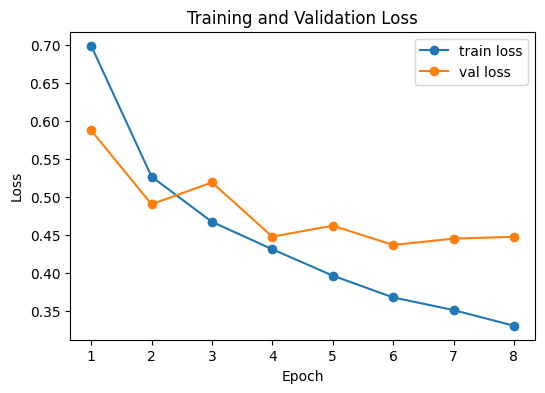

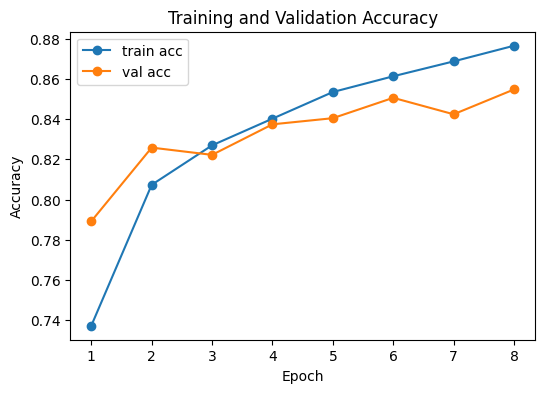

In [111]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, marker="o", label="train loss")
plt.plot(epochs, val_losses, marker="o", label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, train_accuracies, marker="o", label="train acc")
plt.plot(epochs, val_accuracies, marker="o", label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


## 4. Independent test set

Utiliza os 225 eventos etiquetados pelo professor para ter uma medida da acurácia de teste.

Test Accuracy: 0.4622222222222222


<Figure size 800x600 with 0 Axes>

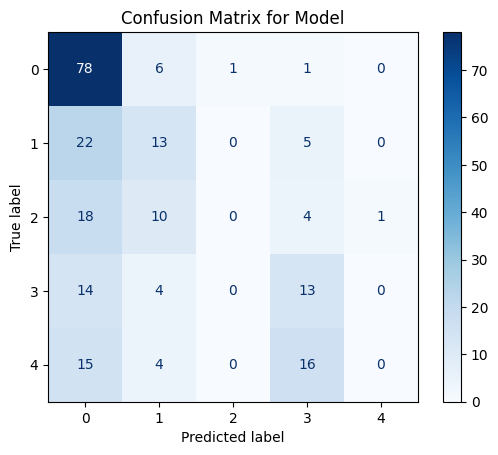

In [112]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load('best_model.pth'))
best_model = model
best_model.eval()
preds_all, labels_all = [], []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        preds = best_model(X).argmax(1)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(y.cpu().numpy())

acc = np.mean(np.array(preds_all) == np.array(labels_all))
print("Test Accuracy:", acc)

cm = confusion_matrix(labels_all, preds_all)

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix for Model')
plt.show()

Gera o arquivo para submissão no github.

In [117]:
from torch.utils.data import Dataset

class PredictionDataset(Dataset):
    def __init__(self, data_list, word_index):
        self.data_list = data_list
        self.word_index = word_index

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        text = item['text']
        # Encode the text using the pre-defined encode function
        encoded_text = encode(text, self.word_index) # max_len is already set in encode function
        # Return only the encoded text, as we don't have true labels for prediction
        return encoded_text

dh_prepared = [{'text': row.Text, 'label': 0} for row in dh.itertuples(index=False)]
dh_dataset = PredictionDataset(dh_prepared, word_index)
dh_loader = DataLoader(dh_dataset, batch_size=32, shuffle=False)

predicted_labels_numerical = []
best_model.eval() # Set model to evaluation mode

with torch.no_grad(): # Disable gradient calculation for inference
    for encoded_texts in dh_loader:
        encoded_texts = encoded_texts.to(device)
        outputs = best_model(encoded_texts)
        preds = outputs.argmax(1) # Get the class with the highest probability
        predicted_labels_numerical.extend(preds.cpu().numpy())

reverse_label_map = {v: k for k, v in label_map.items()}
predicted_labels_string = [reverse_label_map[label_id] for label_id in predicted_labels_numerical]

submission_df = pd.DataFrame({'ID': dh['ID'], 'Label': predicted_labels_string})

submission_df.to_csv('submission.csv', index=False, sep=";")

print("Submission file 'submission.csv' created successfully.")
print(submission_df.head())

Submission file 'submission.csv' created successfully.
       ID      Label
0  D2-101      Human
1  D2-102  Anthropic
2  D2-103      Human
3  D2-104  Anthropic
4  D2-105      Human


## Conclusão até o momento

A acurácia de 85% na base de validação, bem superior aos 46% de acurácia nos testes independentes indicm que, apesar do modelo estar bem treinado, o dataset que estamos utilizando para treinar possui características bem diferentes do dataset utilizado pelo professor para avaliação.

Nos próximos passos, algum esforço deverá ser dispensado para aproximar os resultados de teste com os de validação.